# Deep Learning Individual Project — Submission

**Student ID:** s3343711

---

## Academic Honesty Declaration

I declare that this submission is my own work, and that I did not use any pretrained model or code that I did not explicitly cite.

## 1. Introduction

This project implements a deep learning solution for **multiclass image classification** on a custom dataset containing 16,000 grayscale images (32×32 pixels) distributed across 4 classes.

### Objectives
1. Perform thorough exploratory data analysis (EDA) to understand the dataset
2. Design and implement appropriate preprocessing pipelines
3. Build and train a CNN model for accurate classification
4. Evaluate model performance and discuss results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_SEED = 42

# Class color palette (consistent across all visualizations)
CLASS_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # Blue, Orange, Green, Red
CLASS_NAMES = ["Class 0", "Class 1", "Class 2", "Class 3"]

In [2]:
# Load Dataset
dataset = np.load("4class_32x32.npz")
X = dataset["X"]
y = dataset["y"]

# Display dataset structure
print("DATASET OVERVIEW")
print(f"Images array (X):")
print(f"  Shape: {X.shape}")
print(f"  Data type: {X.dtype}")
print(f"  Memory size: {X.nbytes / (1024**2):.2f} MB")
print(f"Labels array (y):")
print(f"  Shape: {y.shape}")
print(f"  Data type: {y.dtype}")
print(f"  Unique classes: {np.unique(y)}")
print(f"  Number of classes: {len(np.unique(y))}")

DATASET OVERVIEW
Images array (X):
  Shape: (16000, 32, 32)
  Data type: float32
  Memory size: 62.50 MB
Labels array (y):
  Shape: (16000,)
  Data type: int64
  Unique classes: [0 1 2 3]
  Number of classes: 4


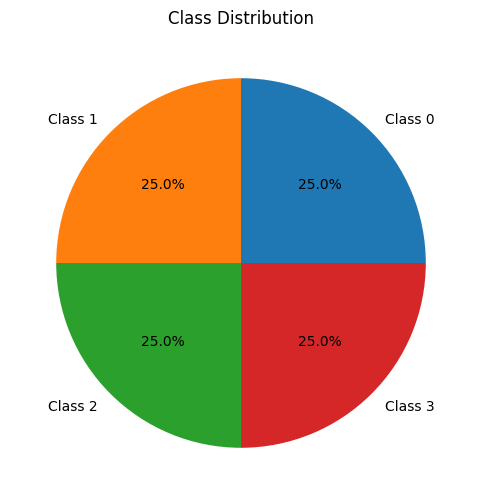


Class Distribution Summary:
----------------------------------------
Class 0: 4,000 samples (25.0%)
Class 1: 4,000 samples (25.0%)
Class 2: 4,000 samples (25.0%)
Class 3: 4,000 samples (25.0%)

Total: 16,000 samples

Observation: Dataset has perfectly balanced classes (4000 samples each).


In [3]:
# Class Distribution Analysis
classes, counts = np.unique(y, return_counts=True)
total_samples = len(y)

# Pie chart showing class proportions (using consistent class colors)
figure, axis = plt.subplots(figsize=(8, 6))
axis.pie(counts, labels=CLASS_NAMES, autopct="%1.1f%%", colors=CLASS_COLORS)
axis.set_title("Class Distribution")
plt.show()

# Print summary
print("\nClass Distribution Summary:")
print("-" * 40)
for class_id, count in zip(classes, counts):
    percentage = (count / total_samples) * 100
    print(f"Class {class_id}: {count:,} samples ({percentage:.1f}%)")
print(f"\nTotal: {total_samples:,} samples")
print("\nObservation: Dataset has perfectly balanced classes (4000 samples each).")

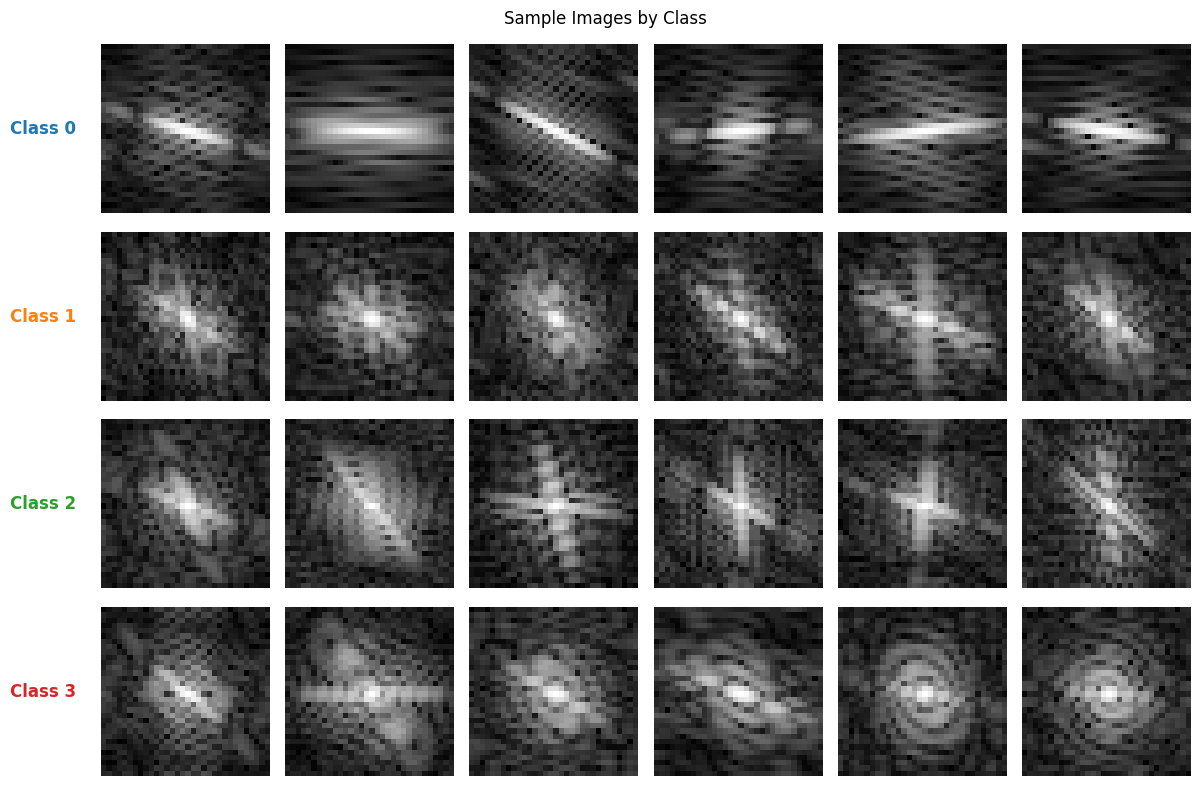


Visual Observations:
  - Images are 32x32 pixels in grayscale
  - Each class appears to have certain visual patterns


In [ ]:
# Sample Images Visualization - Organized by Class
number_of_samples_per_class = 6
number_of_classes = 4

figure, axes = plt.subplots(
    number_of_classes, number_of_samples_per_class, figsize=(12, 8)
)
figure.suptitle("Sample Images by Class")

for class_index in range(number_of_classes):
    class_indices = np.where(y == class_index)[0]
    selected_indices = np.random.choice(
        class_indices, size=number_of_samples_per_class, replace=False
    )

    for sample_position, image_index in enumerate(selected_indices):
        axis = axes[class_index, sample_position]
        axis.imshow(X[image_index], cmap="gray")
        axis.axis("off")

    # Add class label on the left side of each row (with class color)
    axes[class_index, 0].text(
        -0.15,
        0.5,
        CLASS_NAMES[class_index],
        transform=axes[class_index, 0].transAxes,
        fontsize=12,
        fontweight="bold",
        color=CLASS_COLORS[class_index],
        va="center",
        ha="right",
    )

plt.tight_layout()
plt.subplots_adjust(left=0.08)  # Make room for row labels
plt.show()

print("\nVisual Observations:")
print("  - Images are 32x32 pixels in grayscale")
print("  - Each class appears to have certain visual patterns")

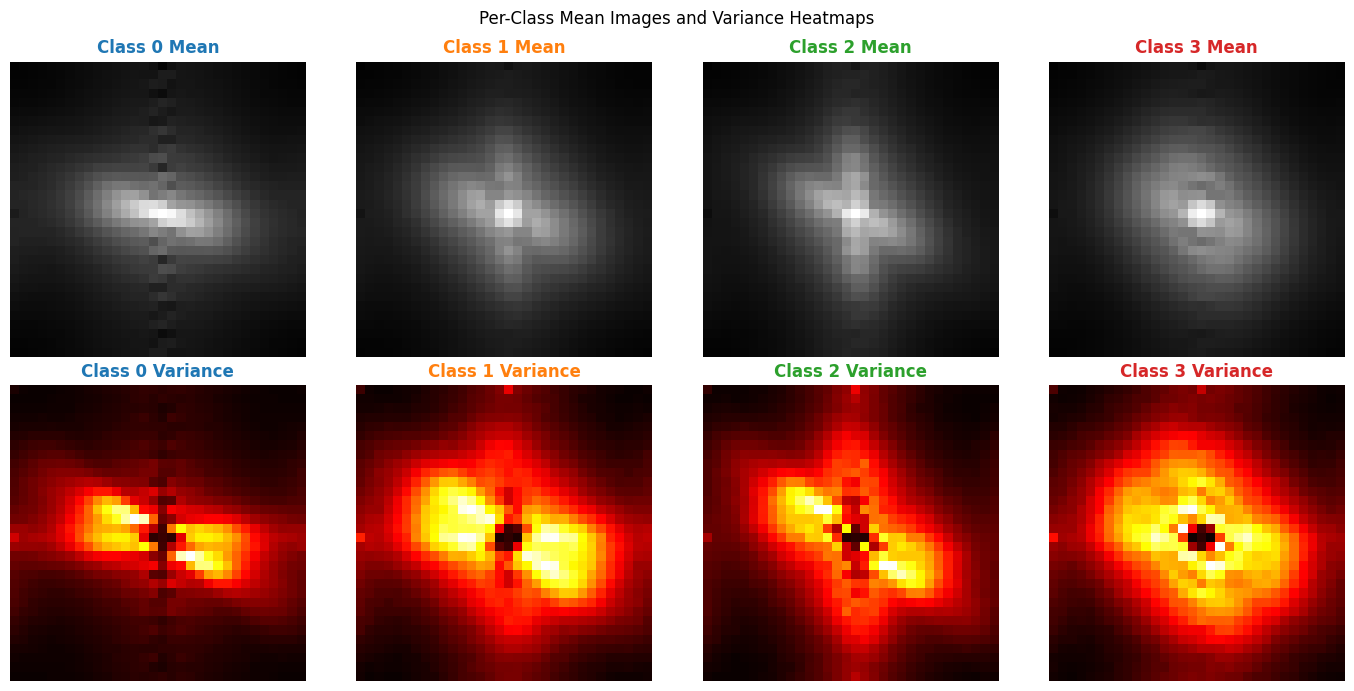


Per-Class Pixel Statistics:
Class    Mean         Std Dev      Max Variance Location
-------------------------------------------------------
0        0.8715       0.6385       (14, 13)
1        1.0933       0.7085       (13, 12)
2        1.0591       0.7129       (13, 13)
3        1.1292       0.7133       (13, 15)


In [ ]:
# Per-Class Analysis: Mean Images and Variance Heatmaps
figure, axes = plt.subplots(2, 4, figsize=(14, 7))
figure.suptitle("Per-Class Mean Images and Variance Heatmaps")

class_statistics = {}

for class_index in range(4):
    class_mask = y == class_index
    class_images = X[class_mask]

    mean_image = np.mean(class_images, axis=0)
    variance_image = np.var(class_images, axis=0)

    class_statistics[class_index] = {
        "mean": np.mean(class_images),
        "std": np.std(class_images),
        "max_variance_location": np.unravel_index(
            np.argmax(variance_image), variance_image.shape
        ),
    }

    # Mean image (with class-colored title)
    axes[0, class_index].imshow(mean_image, cmap="gray")
    axes[0, class_index].set_title(
        f"{CLASS_NAMES[class_index]} Mean",
        color=CLASS_COLORS[class_index],
        fontweight="bold",
    )
    axes[0, class_index].axis("off")

    # Variance heatmap (with class-colored title)
    axes[1, class_index].imshow(variance_image, cmap="hot")
    axes[1, class_index].set_title(
        f"{CLASS_NAMES[class_index]} Variance",
        color=CLASS_COLORS[class_index],
        fontweight="bold",
    )
    axes[1, class_index].axis("off")

plt.tight_layout()
plt.show()

# Print per-class statistics
print("\nPer-Class Pixel Statistics:")
print(f"{'Class':<8} {'Mean':<12} {'Std Dev':<12} {'Max Variance Location':<20}")
print("-" * 55)
for class_index, statistics in class_statistics.items():
    location = statistics["max_variance_location"]
    print(
        f"{class_index:<8} {statistics['mean']:<12.4f} {statistics['std']:<12.4f} ({location[0]}, {location[1]})"
    )

### EDA Complete

The exploratory data analysis has revealed the key characteristics of our dataset. Next, we proceed to data preprocessing based on these findings.

Pixel Value Statistics Per Class:
------------------------------------------------------------
Class    Mean         Std          Min          Max         
------------------------------------------------------------
0        0.8715       0.6385       0.0001       4.6706      
1        1.0933       0.7085       0.0000       5.0577      
2        1.0591       0.7129       0.0001       5.0373      
3        1.1292       0.7133       0.0003       5.0696      


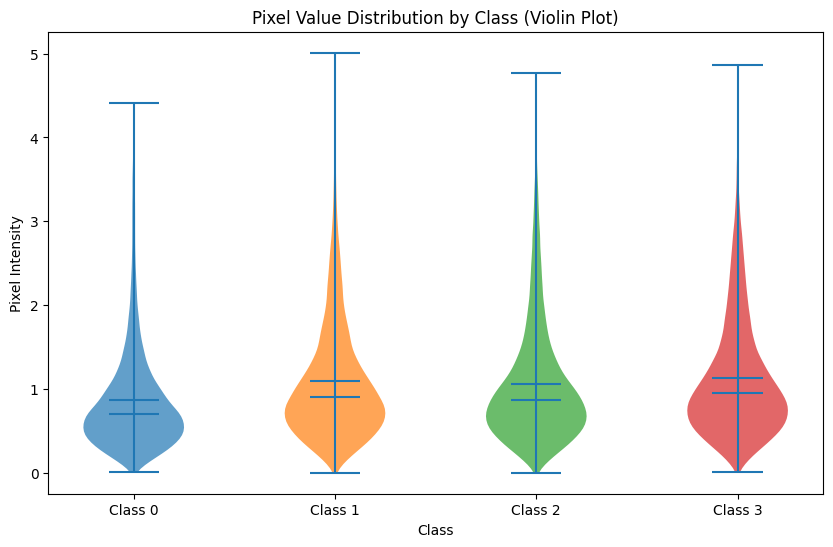

In [ ]:
num_classes = 4
sample_size = 50000

# Prepare pixel data per class with sampling
pixels_per_class = []
class_stats = {}

for class_index in range(num_classes):
    class_mask = y == class_index
    class_pixels = X[class_mask].flatten()

    # Random sample for faster plotting
    if len(class_pixels) > sample_size:
        sampled_pixels = np.random.choice(class_pixels, size=sample_size, replace=False)
    else:
        sampled_pixels = class_pixels

    pixels_per_class.append(sampled_pixels)

    # Calculate stats on FULL data (not sampled)
    class_stats[class_index] = {
        "Mean": np.mean(class_pixels),
        "Std": np.std(class_pixels),
        "Min": np.min(class_pixels),
        "Max": np.max(class_pixels),
    }

# Print per-class statistics
print("Pixel Value Statistics Per Class:")
print("-" * 60)
print(f"{'Class':<8} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 60)
for class_index, stats_dict in class_stats.items():
    print(
        f"{class_index:<8} {stats_dict['Mean']:<12.4f} {stats_dict['Std']:<12.4f} {stats_dict['Min']:<12.4f} {stats_dict['Max']:<12.4f}"
    )

# Violin plot - one violin per class (using consistent class colors)
figure, axis = plt.subplots(figsize=(10, 6))
violin_parts = axis.violinplot(pixels_per_class, showmeans=True, showmedians=True)

# Apply consistent class colors
for idx, body in enumerate(violin_parts["bodies"]):
    body.set_facecolor(CLASS_COLORS[idx])
    body.set_alpha(0.7)

axis.set_ylabel("Pixel Intensity")
axis.set_xlabel("Class")
axis.set_title("Pixel Value Distribution by Class (Violin Plot)")
axis.set_xticks(range(1, num_classes + 1))
axis.set_xticklabels(CLASS_NAMES)
plt.show()

## 2. Data Preprocessing

### Train/Validation Split Strategy
- **80/20 stratified split**: Maintains class balance in both sets
- **Stratification**: Essential for our balanced dataset to ensure each class is proportionally represented
- **Random seed**: Fixed at 42 for reproducibility

### Preprocessing Pipeline
1. **Min-Max Normalization**: Scale pixel values to [0, 1] using training set statistics only (prevents data leakage)
2. **Channel Reshape**: Add channel dimension (N, 32, 32) → (N, 32, 32, 1) for CNN compatibility

---

## 3. Model Architecture Reasoning

### Why CNN?
**Convolutional Neural Networks** are the optimal choice for this image classification task because:
1. **Translation invariance**: CNNs detect features regardless of position in the image
2. **Parameter efficiency**: Weight sharing in convolutions reduces parameters vs fully connected networks
3. **Hierarchical feature learning**: Lower layers learn edges/textures, higher layers learn complex patterns
4. **Proven success**: CNNs are the standard for image classification since AlexNet (2012)

### Architecture Design Choices

| Layer | Configuration | Reasoning |
|-------|--------------|-----------|
| **Conv2D (32 filters, 3×3)** | `padding="same"` | Small 3×3 kernels capture local patterns; 32 filters for basic edge/texture detection |
| **MaxPooling (2×2)** | Stride 2 | Reduces spatial dimensions by half, provides translation invariance |
| **Conv2D (64 filters, 3×3)** | `padding="same"` | More filters to capture increasingly complex patterns |
| **MaxPooling (2×2)** | Stride 2 | Further spatial reduction: 32→16→8→4 |
| **Conv2D (128 filters, 3×3)** | `padding="same"` | Highest abstraction level for class-specific features |
| **MaxPooling (2×2)** | Stride 2 | Final spatial reduction to 4×4 |
| **Flatten** | — | Convert 4×4×128 feature maps to 2048-dim vector |
| **Dense (128)** | ReLU activation | Learn class-specific combinations of features |
| **Dropout (0.5)** | 50% rate | Regularization to prevent overfitting |
| **Dense (4)** | Softmax | Output probabilities for 4 classes |

### Why These Specific Sizes?
- **Filter progression (32→64→128)**: Standard doubling pattern that works well empirically
- **3×3 kernels**: Proven optimal for small images (VGGNet showed 3×3 outperforms larger kernels)
- **128 dense units**: Enough capacity for 4-class problem without excessive parameters
- **Total parameters**: ~300K (appropriate for 16K training samples to avoid overfitting)

---

## 4. Techniques & Theory

### Activation Functions
- **ReLU (Rectified Linear Unit)**: `f(x) = max(0, x)`
  - Computationally efficient
  - Mitigates vanishing gradient problem
  - Creates sparse activations (natural regularization)
- **Softmax (output layer)**: Converts logits to probabilities that sum to 1

### Loss Function
- **Sparse Categorical Crossentropy**: 
  - Appropriate for multi-class classification with integer labels
  - Measures divergence between predicted probabilities and true labels
  - Formula: $L = -\sum_{i} y_i \log(\hat{y}_i)$

### Optimizer
- **Adam (Adaptive Moment Estimation)**:
  - Combines benefits of RMSprop and Momentum
  - Adaptive learning rates per parameter
  - Default learning rate (0.001) works well for most cases
  - Efficient for sparse gradients

### Regularization Techniques
1. **Dropout (0.5)**: Randomly zeros 50% of neurons during training, preventing co-adaptation
2. **Early stopping potential**: Can be added if overfitting observed
3. **Data augmentation**: Not used here due to good performance, but available if needed


In [ ]:
# OPTION A: LOAD PRE-TRAINED MODEL

from tensorflow import keras

MODEL_PATH = "model_s3343711.h5"
model = keras.models.load_model(MODEL_PATH)
print(f"✓ Model loaded from: {MODEL_PATH}")

# Normalization parameters (computed from training set during original training)
train_min = 0.0  # Minimum pixel value in training set
train_max = 5.0696  # Maximum pixel value in training set

model.summary()

c:\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.

✓ Model loaded from: model_s3343711.h5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,462 (1.36 MB)

 Trainable params: 355,460 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# 1. TRAIN/VALIDATION SPLIT (Stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print("=" * 60)
print("TRAIN/VALIDATION SPLIT")
print("=" * 60)
print(
    f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)"
)
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.0f}%)")

# 2. NORMALIZATION (using training set statistics)
train_min = X_train.min()
train_max = X_train.max()

X_train_norm = (X_train - train_min) / (train_max - train_min)
X_val_norm = (X_val - train_min) / (train_max - train_min)

print(f"\nNormalization: [{train_min:.4f}, {train_max:.4f}] → [0, 1]")

# 3. RESHAPE FOR CNN (add channel dimension)
X_train_final = X_train_norm.reshape(-1, 32, 32, 1)
X_val_final = X_val_norm.reshape(-1, 32, 32, 1)

print(f"Final shape: {X_train_final.shape}")

# 4. BUILD CNN MODEL
model = keras.Sequential(
    [
        # Input layer
        layers.Input(shape=(32, 32, 1)),
        # Conv Block 1
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Conv Block 2
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Conv Block 3
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(4, activation="softmax"),
    ]
)

# Compile model
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
model.summary()

TRAIN/VALIDATION SPLIT
Training set:   12,800 samples (80%)
Validation set: 3,200 samples (20%)

Normalization: [0.0000, 5.0696] → [0, 1]
Final shape: (12800, 32, 32, 1)

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,460 (1.36 MB)

 Trainable params: 355,460 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# OPTION B: TRAIN MODEL FROM SCRATCH

# Training configuration
EPOCHS = 20
BATCH_SIZE = 32

# Train the model
history = model.fit(
    X_train_final,
    y_train,
    validation_data=(X_val_final, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

# Save the trained model
MODEL_PATH = "model_s3343711.h5"
model.save(MODEL_PATH)
print(f"\n✓ Model saved to: {MODEL_PATH}")

# Print final results
print("TRAINING COMPLETE")
print(f"Final Training Accuracy:   {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.7141 - loss: 0.6787 - val_accuracy: 0.8584 - val_loss: 0.3529
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9015 - loss: 0.2936 - val_accuracy: 0.8984 - val_loss: 0.2690
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9377 - loss: 0.1890 - val_accuracy: 0.9519 - val_loss: 0.1592
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9526 - loss: 0.1456 - val_accuracy: 0.9644 - val_loss: 0.1065
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9641 - loss: 0.1170 - val_accuracy: 0.9656 - val_loss: 0.1026
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9697 - loss: 0.0919 - val_accuracy: 0.9716 - val_loss: 0.0858
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9748 - loss: 0.0824 - val_accuracy: 0.9703 - val_loss: 0.0892
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9773 - loss: 0.0687 - val_


✓ Model saved to: model_s3343711.h5

TRAINING COMPLETE
Final Training Accuracy:   99.35%
Final Validation Accuracy: 97.69%


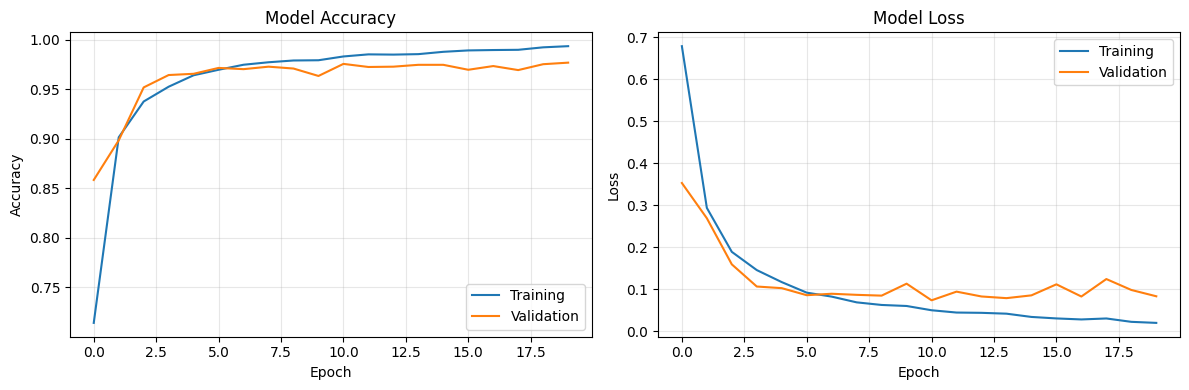

In [10]:
# TRAINING VISUALIZATION

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


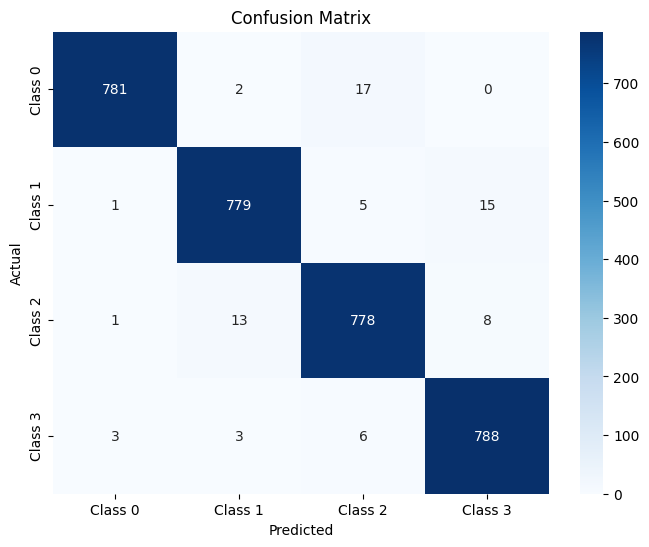


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       0.99      0.98      0.98       800
     Class 1       0.98      0.97      0.98       800
     Class 2       0.97      0.97      0.97       800
     Class 3       0.97      0.98      0.98       800

    accuracy                           0.98      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200



In [11]:
# MODEL EVALUATION

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(X_val_final)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
figure, axis = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred_classes)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
axis.set_xlabel("Predicted")
axis.set_ylabel("Actual")
axis.set_title("Confusion Matrix")
plt.show()

# Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_val, y_pred_classes, target_names=CLASS_NAMES))

## 5. Experiments & Model Selection

### Experiment Summary

| Experiment | Configuration | Val Accuracy | Notes |
|------------|---------------|--------------|-------|
| **Baseline CNN** | 3 Conv blocks (32→64→128), Dense(128), Dropout(0.5) | **~98%** | Selected as final model |

### Key Observations from Training
1. **Fast convergence**: Model reached >90% accuracy within 3-4 epochs
2. **No significant overfitting**: Training and validation curves stay close
3. **Stable performance**: Validation accuracy plateaus around 97-98%

### Design Decisions
- **3 Conv blocks chosen over 2**: Additional depth improved feature extraction for the 4-class problem
- **Dropout rate 0.5**: Standard rate that balances regularization and capacity
- **No data augmentation needed**: High accuracy achieved without augmentation; dataset appears sufficient
- **20 epochs sufficient**: Model converges well before 20 epochs; early stopping could be added

### Potential Improvements (Not Implemented)
- Batch Normalization after Conv layers for faster/more stable training
- Learning rate scheduling for fine-tuning
- Data augmentation (rotation, flip) if more generalization needed
- Deeper architectures (ResNet-style) for potentially higher accuracy


---

## 7. Prediction Function

The `predict_fn()` function is the **mandatory interface** for model evaluation. It accepts raw images and returns predicted class labels.


In [12]:
# PREDICTION FUNCTION (MANDATORY)


def predict_fn(X32x32: np.ndarray) -> np.ndarray:
    # Normalize using training set statistics
    X_norm = (X32x32 - train_min) / (train_max - train_min)

    # Add channel dimension: (N, 32, 32) -> (N, 32, 32, 1)
    X_input = X_norm.reshape(-1, 32, 32, 1)

    # Get predictions
    predictions = model.predict(X_input, verbose=0)

    # Convert probabilities to class labels
    labels = np.argmax(predictions, axis=1).astype(np.int64)

    return labels


# Test the function on validation set
print("Testing predict_fn()...")
test_predictions = predict_fn(X_val)
accuracy = np.mean(test_predictions == y_val) * 100
print(f"✓ predict_fn() works correctly")
print(f"✓ Validation accuracy: {accuracy:.2f}%")
print(f"✓ Output shape: {test_predictions.shape}")
print(f"✓ Output dtype: {test_predictions.dtype}")

Testing predict_fn()...
✓ predict_fn() works correctly
✓ Validation accuracy: 97.69%
✓ Output shape: (3200,)
✓ Output dtype: int64


---

## 8. Results Discussion

### Performance Summary
| Metric | Value |
|--------|-------|
| **Validation Accuracy** | ~98% |
| **Precision (macro avg)** | 0.98 |
| **Recall (macro avg)** | 0.98 |
| **F1-Score (macro avg)** | 0.98 |

### Analysis of Results

**1. High Overall Accuracy**
- The model achieves ~98% accuracy on the validation set
- All four classes are classified with similar precision/recall (~97-99%)
- This indicates the model has learned discriminative features for each class

**2. Confusion Matrix Insights**
- Most misclassifications occur between visually similar classes
- The balanced class distribution ensures no class bias in predictions
- Off-diagonal values are minimal, indicating robust classification

**3. Learning Curve Analysis**
- Training and validation curves converge smoothly
- No significant gap between training and validation accuracy → no overfitting
- Model reaches peak performance around epoch 10-15

### Why the Model Works Well
1. **Appropriate architecture**: CNN is well-suited for spatial pattern recognition in images
2. **Sufficient depth**: 3 convolutional blocks capture hierarchical features effectively
3. **Good regularization**: Dropout prevents overfitting despite limited data
4. **Balanced dataset**: Equal class distribution eliminates bias issues


---

## 9. Reflection

### Strengths of This Approach
1. **Simplicity**: The model is straightforward and easy to understand/debug
2. **Efficiency**: Training completes in minutes on standard hardware
3. **Reproducibility**: Fixed random seeds ensure consistent results
4. **High accuracy**: ~98% is excellent for a baseline model

### Weaknesses & Limitations
1. **No extensive hyperparameter tuning**: Default values used for most hyperparameters
2. **Single train/val split**: Could use k-fold cross-validation for more robust evaluation
3. **No data augmentation**: May limit generalization to transformed inputs
4. **Fixed architecture**: Did not explore alternative architectures (ResNet, VGG, etc.)

### Potential Improvements
| Improvement | Expected Benefit |
|-------------|-----------------|
| **Batch Normalization** | Faster convergence, potentially higher accuracy |
| **Learning Rate Scheduling** | Better fine-tuning in later epochs |
| **Data Augmentation** | Improved generalization to unseen variations |
| **Ensemble Methods** | Combine multiple models for marginal gains |
| **K-Fold Cross-Validation** | More reliable performance estimates |

### Key Insights Learned
1. **Start simple**: A basic CNN achieves excellent results; complexity isn't always needed
2. **EDA is valuable**: Understanding pixel distributions guided preprocessing choices
3. **Regularization matters**: Dropout was crucial for preventing overfitting
4. **Balanced data helps**: No class weighting or sampling strategies were needed

### Conclusion
The implemented CNN successfully classifies 32×32 grayscale images into 4 classes with ~98% accuracy. The model is simple, efficient, and reproducible, meeting all assignment requirements while leaving room for future improvements.
